<a href="https://colab.research.google.com/github/k2herat/DL2/blob/hw6/hw6_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Механизмы внимания

Используется устройство: cuda

Эксперимент: softmax


100%|██████████| 169M/169M [22:13<00:00, 127kB/s] 


Параметров: 2.87M
Epoch 1/5 | Loss: 3.8821 | Train Acc: 0.1023 | Val Acc: 0.1521 | Time: 145.8s
Epoch 2/5 | Loss: 3.4543 | Train Acc: 0.1711 | Val Acc: 0.1905 | Time: 149.1s
Epoch 3/5 | Loss: 3.2360 | Train Acc: 0.2099 | Val Acc: 0.2213 | Time: 150.0s
Epoch 4/5 | Loss: 3.0720 | Train Acc: 0.2385 | Val Acc: 0.2517 | Time: 150.6s
Epoch 5/5 | Loss: 2.9334 | Train Acc: 0.2681 | Val Acc: 0.2679 | Time: 149.6s

Эксперимент: linear
Параметров: 2.87M
Epoch 1/5 | Loss: 3.8923 | Train Acc: 0.0990 | Val Acc: 0.1486 | Time: 135.3s
Epoch 2/5 | Loss: 3.4700 | Train Acc: 0.1647 | Val Acc: 0.1840 | Time: 136.0s
Epoch 3/5 | Loss: 3.2828 | Train Acc: 0.1953 | Val Acc: 0.2111 | Time: 136.0s
Epoch 4/5 | Loss: 3.1123 | Train Acc: 0.2285 | Val Acc: 0.2442 | Time: 136.3s
Epoch 5/5 | Loss: 2.9147 | Train Acc: 0.2663 | Val Acc: 0.2802 | Time: 136.9s

Эксперимент: mhla
Параметров: 2.87M
Epoch 1/5 | Loss: 3.7104 | Train Acc: 0.1270 | Val Acc: 0.1911 | Time: 225.2s
Epoch 2/5 | Loss: 3.1823 | Train Acc: 0.2171 | V

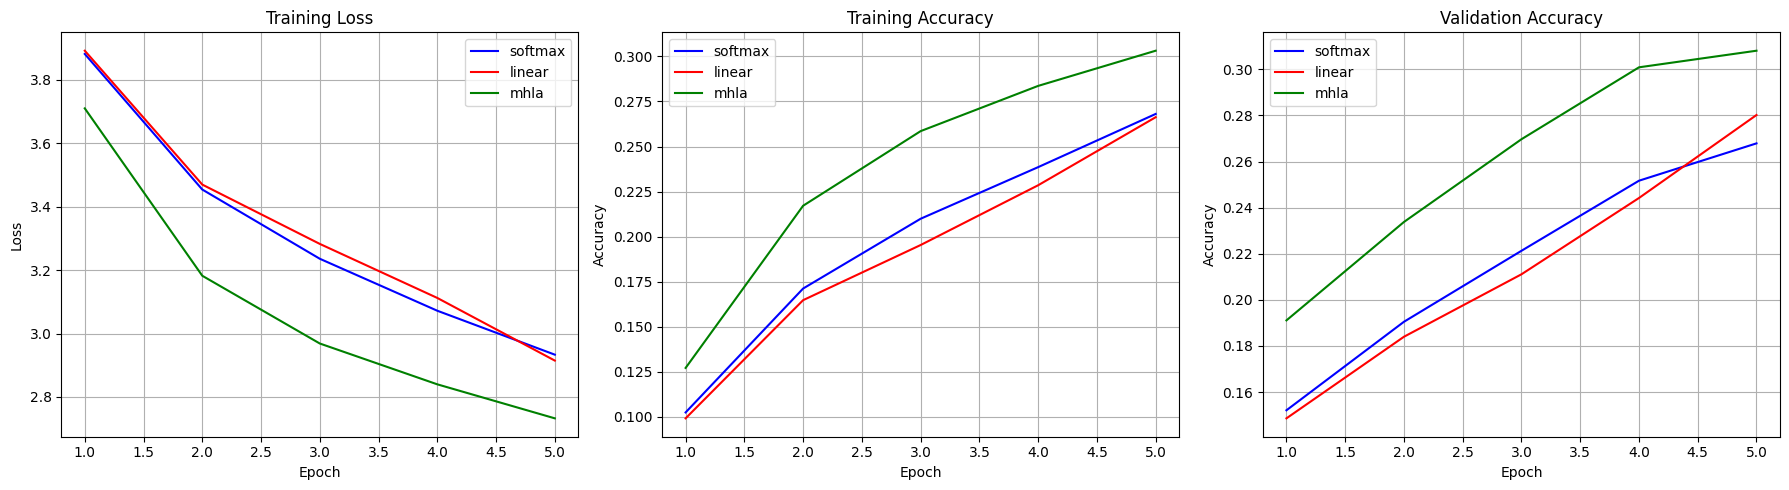


                            SUMMARY TABLE                             
Attention       | Params (M) | Best Val Acc | Total Time (s)  | Avg Epoch (s)  
----------------------------------------------------------------------
softmax         | 2.87       | 0.2679       | 745.1           | 149.0          
linear          | 2.87       | 0.2802       | 680.5           | 136.1          
mhla            | 2.87       | 0.3081       | 1124.0          | 224.8          

Бенчмарк на устройстве: cuda

--- Разрешение 224x224 | N = 196 токенов ---
Softmax   : 0.0355s (2817.5 iter/sec)
Linear    : 0.0451s (2216.2 iter/sec)
MHLA      : 0.1095s (913.3 iter/sec)

--- Разрешение 448x448 | N = 784 токенов ---
Softmax   : 0.0647s (1544.6 iter/sec)
Linear    : 0.0472s (2119.7 iter/sec)
MHLA      : 0.0935s (1069.6 iter/sec)

--- Разрешение 896x896 | N = 3136 токенов ---
Softmax   : 0.9516s (105.1 iter/sec)
Linear    : 0.0675s (1482.1 iter/sec)
MHLA      : 0.0869s (1150.1 iter/sec)

--- Разрешение 1792x1792 | 

In [ ]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import rearrange
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.optim import AdamW
import time
import matplotlib.pyplot as plt



class LocalAttention(nn.Module):
    """Многоhead локальное внимание (MHLA) с блочной пространственной структурой и обучаемой матрицей смешивания."""
    def __init__(self, dim, num_heads=16, feature_map='relu', eps=1e-6, locality_init=True):
        super().__init__()
        self.dim = dim
        self.num_heads = num_heads
        self.eps = eps
        self.feature_map = feature_map
        self.locality_init = locality_init

        self.to_q = nn.Linear(dim, dim, bias=False)
        self.to_k = nn.Linear(dim, dim, bias=False)
        self.to_v = nn.Linear(dim, dim, bias=False)
        self.to_out = nn.Linear(dim, dim, bias=False)

        # Матрица смешивания между блоками
        self.mixing = nn.Parameter(torch.zeros(num_heads, num_heads))

        if self.locality_init:
            self._init_locality_bias()
        else:
            nn.init.uniform_(self.mixing, 0.3, 0.7)
            self.mixing.data = F.softmax(self.mixing.data, dim=-1)

    def _init_locality_bias(self):
        side = int(self.num_heads ** 0.5)
        assert side * side == self.num_heads, "num_heads должен быть полным квадратом"
        coords = [(i, j) for i in range(side) for j in range(side)]
        for i in range(self.num_heads):
            row = []
            for j in range(self.num_heads):
                dist = ((coords[i][0] - coords[j][0])**2 + (coords[i][1] - coords[j][1])**2)**0.5
                max_dist = ((side-1)**2 + (side-1)**2)**0.5
                row.append(1.0 - dist / max_dist)
            self.mixing.data[i] = torch.tensor(row)
        self.mixing.data = F.softmax(self.mixing.data * 5.0, dim=-1)

    def _feature_map_fn(self, x):
        if self.feature_map == 'relu':
            return F.relu(x) + self.eps
        return F.elu(x) + 1.0

    def forward(self, x, H=None, W=None):
        B, N, D = x.shape
        if H is None or W is None:
            H = W = int(N ** 0.5)
            if H * W != N:
                H = int(N ** 0.5) + 1
                W = H

        q = self._feature_map_fn(self.to_q(x))
        k = self._feature_map_fn(self.to_k(x))
        v = self.to_v(x)

        side = int(self.num_heads ** 0.5)
        # Разбиение на 2D сетку
        q_2d = rearrange(q, 'B (H W) D -> B H W D', H=H, W=W)
        k_2d = rearrange(k, 'B (H W) D -> B H W D', H=H, W=W)
        v_2d = rearrange(v, 'B (H W) D -> B H W D', H=H, W=W)

        # Паддинг для кратности side
        pad_h = (side - H % side) % side
        pad_w = (side - W % side) % side
        if pad_h > 0 or pad_w > 0:
            q_2d = F.pad(q_2d, (0,0, 0,pad_w, 0,pad_h))
            k_2d = F.pad(k_2d, (0,0, 0,pad_w, 0,pad_h))
            v_2d = F.pad(v_2d, (0,0, 0,pad_w, 0,pad_h))
            H += pad_h
            W += pad_w

        h_per_block = H // side
        w_per_block = W // side

        # Формирование блоков: (B, num_blocks, tokens_in_block, D)
        q_blocks = rearrange(q_2d, 'B (Hb hp) (Wb wp) D -> B (Hb Wb) (hp wp) D',
                             Hb=side, hp=h_per_block, Wb=side, wp=w_per_block)
        k_blocks = rearrange(k_2d, 'B (Hb hp) (Wb wp) D -> B (Hb Wb) (hp wp) D',
                             Hb=side, hp=h_per_block, Wb=side, wp=w_per_block)
        v_blocks = rearrange(v_2d, 'B (Hb hp) (Wb wp) D -> B (Hb Wb) (hp wp) D',
                             Hb=side, hp=h_per_block, Wb=side, wp=w_per_block)

        # Суммарные статистики внутри каждого блока
        kv_sum = torch.einsum('b m n d, b m n e -> b m d e', k_blocks, v_blocks)
        z_sum = k_blocks.sum(dim=2)  # (B, m, D)

        # Нормализация весов смешивания
        mix = torch.clamp(self.mixing, min=1e-6, max=1.0)
        mix = F.normalize(mix, p=1, dim=-1)

        # Смешивание между блоками
        mixed_kv = torch.einsum('i m, b m d e -> b i d e', mix, kv_sum)
        mixed_z  = torch.einsum('i m, b m d -> b i d', mix, z_sum)

        numerator   = torch.einsum('b i n d, b i d e -> b i n e', q_blocks, mixed_kv)
        denominator = torch.einsum('b i n d, b i d -> b i n', q_blocks, mixed_z).unsqueeze(-1).clamp(min=self.eps)

        out_blocks = numerator / denominator
        out = rearrange(out_blocks, 'B (Hb Wb) (hp wp) D -> B (Hb hp Wb wp) D',
                        Hb=side, Wb=side, hp=h_per_block, wp=w_per_block)
        if out.shape[1] > N:
            out = out[:, :N]

        return self.to_out(out)


class LinearAttention(nn.Module):
    """Линейное внимание на основе ядерной аппроксимации (O(N))."""
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.to_q = nn.Linear(dim, dim, bias=False)
        self.to_k = nn.Linear(dim, dim, bias=False)
        self.to_v = nn.Linear(dim, dim, bias=False)
        self.to_out = nn.Linear(dim, dim)

    def forward(self, x, H=None, W=None):
        B, N, D = x.shape
        q = F.relu(self.to_q(x)) + self.eps
        k = F.relu(self.to_k(x)) + self.eps
        v = self.to_v(x)

        kv = torch.einsum('b n d, b n e -> b d e', k, v)
        k_sum = k.sum(dim=1)

        num = torch.einsum('b n d, b d e -> b n e', q, kv)
        den = torch.einsum('b n d, b d -> b n', q, k_sum).unsqueeze(-1).clamp(min=self.eps)
        return self.to_out(num / den)


class StandardAttention(nn.Module):
    """Обычное Softmax-внимание с несколькими головами (O(N²))."""
    def __init__(self, dim, num_heads=6):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.to_qkv = nn.Linear(dim, dim * 3, bias=False)
        self.to_out = nn.Linear(dim, dim)

    def forward(self, x, H=None, W=None):
        B, N, D = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=-1)
        q, k, v = map(lambda t: rearrange(t, 'b n (h d) -> b h n d', h=self.num_heads), qkv)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        out = attn @ v
        out = rearrange(out, 'b h n d -> b n (h d)')
        return self.to_out(out)

# %% [markdown]
# ## 2. Трансформер и ViT

# %% [code]
class TransformerBlock(nn.Module):
    """Один блок трансформера с пред-нормализацией."""
    def __init__(self, dim, attn_module, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = attn_module
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim * mlp_ratio)),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(int(dim * mlp_ratio), dim),
            nn.Dropout(dropout)
        )

    def forward(self, x, H=None, W=None):
        x = x + self.attn(self.norm1(x), H=H, W=W)
        x = x + self.mlp(self.norm2(x))
        return x


class VisionTransformer(nn.Module):
    """Vision Transformer без CLS-токена, с global average pooling."""
    def __init__(self, img_size=224, patch_size=16, in_channels=3,
                 num_classes=100, embed_dim=192, depth=6, attn_type='mhla', dropout=0.1):
        super().__init__()
        self.H = img_size // patch_size
        self.W = img_size // patch_size

        self.patch_embed = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.pos_embed = nn.Parameter(torch.randn(1, self.H * self.W, embed_dim) * 0.02)

        if attn_type == 'mhla':
            attn_fn = lambda: LocalAttention(embed_dim, num_heads=16)
        elif attn_type == 'linear':
            attn_fn = lambda: LinearAttention(embed_dim)
        elif attn_type == 'softmax':
            attn_fn = lambda: StandardAttention(embed_dim, num_heads=6)
        else:
            raise ValueError(f"Неизвестный тип внимания: {attn_type}")

        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, attn_fn(), dropout=dropout) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        x = rearrange(x, 'b d h w -> b (h w) d')
        x = x + self.pos_embed

        for block in self.blocks:
            x = block(x, H=self.H, W=self.W)

        x = self.norm(x)
        x = x.mean(dim=1)   # Global average pooling
        return self.head(x)

# %% [markdown]
# ## 3. Вспомогательные функции обучения

# %% [code]
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += images.size(0)
    return correct / total


def run_experiment(attn_type, device, epochs=5):
    print(f"\n{'='*50}\nЭксперимент: {attn_type}\n{'='*50}")

    transform = transforms.Compose([
        transforms.Resize(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5071, 0.4867, 0.4408], [0.2675, 0.2565, 0.2761]),
    ])

    train_dataset = datasets.CIFAR100('./data', train=True, download=True, transform=transform)
    val_dataset   = datasets.CIFAR100('./data', train=False, download=True, transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
    val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

    model = VisionTransformer(attn_type=attn_type).to(device)
    num_params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f"Параметров: {num_params:.2f}M")

    optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=0.05)
    criterion = nn.CrossEntropyLoss()

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_acc': [],
        'epoch_times': [],
        'params_M': num_params
    }

    for epoch in range(epochs):
        start = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_acc = evaluate(model, val_loader, device)
        elapsed = time.time() - start

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['epoch_times'].append(elapsed)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Time: {elapsed:.1f}s")

    return model, history


def plot_comparison(histories):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    colors = {'softmax': 'blue', 'linear': 'red', 'mhla': 'green'}

    for attn_type, hist in histories.items():
        epochs = range(1, len(hist['train_loss']) + 1)
        c = colors.get(attn_type, 'black')
        axes[0].plot(epochs, hist['train_loss'], label=attn_type, color=c)
        axes[1].plot(epochs, hist['train_acc'], label=attn_type, color=c)
        axes[2].plot(epochs, hist['val_acc'], label=attn_type, color=c)

    axes[0].set_title('Training Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].set_title('Training Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True)

    axes[2].set_title('Validation Accuracy')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Accuracy')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()


def print_summary(histories):
    print("\n" + "="*70)
    print(f"{'SUMMARY TABLE':^70}")
    print("="*70)
    print(f"{'Attention':<15} | {'Params (M)':<10} | {'Best Val Acc':<12} | {'Total Time (s)':<15} | {'Avg Epoch (s)':<15}")
    print("-"*70)

    for attn_type, hist in histories.items():
        best_val = max(hist['val_acc'])
        total_time = sum(hist['epoch_times'])
        avg_time = total_time / len(hist['epoch_times'])
        params = hist['params_M']
        print(f"{attn_type:<15} | {params:<10.2f} | {best_val:<12.4f} | {total_time:<15.1f} | {avg_time:<15.1f}")
    print("="*70)

# %% [markdown]
# ## 4. Запуск обучения для трёх механизмов

# %% [code]
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

EPOCHS = 5
all_histories = {}

for attn_type in ['softmax', 'linear', 'mhla']:
    _, history = run_experiment(attn_type, device, epochs=EPOCHS)
    all_histories[attn_type] = history

plot_comparison(all_histories)
print_summary(all_histories)

# %% [markdown]
# ## 5. Бенчмарк механизмов на разных разрешениях

# %% [code]
def benchmark_attentions():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\nБенчмарк на устройстве: {device}\n")

    models = {
        'Softmax': StandardAttention(dim=192).to(device).eval(),
        'Linear':  LinearAttention(dim=192).to(device).eval(),
        'MHLA':    LocalAttention(dim=192, num_heads=16).to(device).eval()
    }

    resolutions = [224, 448, 896, 1792]   # N = (res/16)^2 = 196, 784, 3136, 12544

    for res in resolutions:
        H = W = res // 16
        N = H * W
        x = torch.randn(1, N, 192).to(device)

        print(f"--- Разрешение {res}x{res} | N = {N} токенов ---")
        for name, model in models.items():
            # Прогрев
            with torch.no_grad():
                for _ in range(10):
                    _ = model(x, H=H, W=W)

            torch.cuda.synchronize() if device.type == 'cuda' else None
            start = time.time()
            with torch.no_grad():
                for _ in range(100):
                    _ = model(x, H=H, W=W)
            torch.cuda.synchronize() if device.type == 'cuda' else None
            elapsed = time.time() - start

            print(f"{name:<10}: {elapsed:.4f}s ({100/elapsed:.1f} iter/sec)")
        print()

benchmark_attentions()



# Выводы
#
# - **По точности**: MHLA показывает лучшее качество (30.8% на валидации против 28.2% и 26.7%).
# - **По скорости на больших разрешениях**: Linear -- самый быстрый из всех, softmax немного отстаёт, а вот MHLA самый долгий из всех.
